# The graph prior, starting from `PriorConfig`

This fork makes the causal **graph** a first-class object in TabICL's synthetic prior.
The `graph_scm` prior generates every dataset by

1. sampling a random **causal DAG**,
2. attaching a random **function** to each edge, and
3. pushing noise through the graph to produce the feature/target columns.

A single dataclass — [`PriorConfig`](../src/tabicl/prior/graph_lib/_config.py) — controls
every knob of that process (graph size and density, which edge-function families are
allowed, categorical handling, noise, dataset filtering, …). This notebook is organised
**from that config outward**, peeling back one layer at a time:

| layer | object | what the config controls here |
|------|--------|-------------------------------|
| graph | `RandomCauchyDAG` | `min_n_nodes`, `max_n_nodes`, `cauchy_dag_offset` |
| dataset | `RandomDataset` | edge functions, categorical modes, filtering, noise |
| wrapper | `GraphSCM` | standardisation, padding, permutation |
| public API | `PriorDataset(prior_type="graph_scm", config=…)` | batching over all of the above |

The file is a [`# %%` cell script](https://code.visualstudio.com/docs/python/jupyter-support-py):
it runs top-to-bottom as a plain `python` script *and* opens as an interactive notebook.
Everything runs on CPU with tiny sizes so it finishes in a few seconds. No figures are
written to disk — plots render inline only.

In [1]:
%matplotlib inline
import dataclasses

import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt

from tabicl.prior.graph_lib._config import PriorConfig

SEED = 0


def reseed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)


reseed()

/Users/elias/anaconda3/envs/tfm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. The config object

`PriorConfig` is a plain dataclass of defaults. Creating one with no arguments gives the
configuration used during standard pre-training; every field below is a lever you can pull.

In [2]:
config = PriorConfig()
for f in dataclasses.fields(config):
    print(f"{f.name:35s} = {getattr(config, f.name)!r}")

add_gaussian_noise                  = False
use_node_feature_importance         = True
use_node_importance                 = True
use_node_l2_norm                    = True
allow_act_warping                   = False
allow_kumaraswamy_warping           = True
disallow_y_warping                  = False
max_discretization_cardinality      = 256
filter_unpredictable_datasets       = False
filter_unpredictable_graphs         = False
min_n_nodes                         = 2
max_n_nodes                         = 32
cauchy_dag_offset                   = 0.0
meta_sampling_mode                  = 'meta'
random_matrix_types                 = 'default'
fct_types                           = 'default'
multi_fct_types                     = 'default'
cat_modes                           = 'default'
random_weights_types                = 'simple'
subsample_feature_nodes             = True
seq_lens_multiple_of                = 1
use_corrected_num_converters        = False
use_corrected_cat_sizes         

## 1. From the config to a causal DAG

The graph itself is sampled by [`RandomCauchyDAG`](../src/tabicl/prior/graph_lib/_graph.py),
which reads `min_n_nodes` / `max_n_nodes` (size) and `cauchy_dag_offset` (density) from the
config. A DAG is returned as a **list of parents per node**: `dag[i]` is the list of nodes
feeding into node `i`. Because parents always have smaller indices, the graph is acyclic by
construction.

parents per node:
  node 0: parents=[]
  node 1: parents=[0]
  node 2: parents=[0, 1]
  node 3: parents=[0, 1, 2]
  node 4: parents=[0, 1, 2, 3]
  node 5: parents=[1, 2, 4]
  node 6: parents=[0, 1, 2, 3, 4, 5]
  node 7: parents=[0, 1, 4, 5]
  node 8: parents=[]
  node 9: parents=[0, 1, 2, 3, 4, 5, 6, 7, 8]


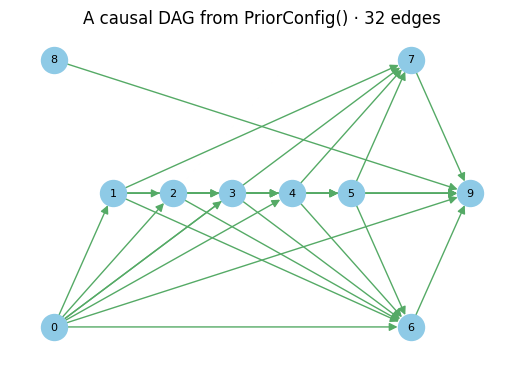

In [3]:
from tabicl.prior.graph_lib._base import Context
from tabicl.prior.graph_lib._graph import RandomCauchyDAG


def sample_dag(cfg, n_nodes, seed=SEED):
    """Sample a DAG straight from a config (parents-per-node representation)."""
    reseed(seed)
    return RandomCauchyDAG(Context(config=cfg, device="cpu")).sample(n_nodes)


def dag_to_nx(dag):
    """List-of-parents -> networkx.DiGraph."""
    G = nx.DiGraph()
    G.add_nodes_from(range(len(dag)))
    for child, parents in enumerate(dag):
        for p in parents:
            G.add_edge(p, child)
    return G


def layered_pos(G):
    """Left-to-right layout by topological depth: roots (causes) left, effects right."""
    pos = {}
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for i, n in enumerate(sorted(nodes)):
            pos[n] = (layer, i - (len(nodes) - 1) / 2)
    return pos


def draw_dag(dag, ax, title=""):
    G = dag_to_nx(dag)
    nx.draw(
        G, layered_pos(G), ax=ax, with_labels=True, font_size=8,
        node_size=350, node_color="#8ecae6", arrowsize=12, 
        edge_color="#5a6",
    )
    ax.set_title(title)
    return G


dag = sample_dag(config, n_nodes=10)
print("parents per node:")
for i, parents in enumerate(dag):
    print(f"  node {i}: parents={parents}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
draw_dag(dag, ax, title=f"A causal DAG from PriorConfig() · {dag_to_nx(dag).number_of_edges()} edges")
plt.show()

## 2. Config knobs that shape the graph

**Density — `cauchy_dag_offset`.** Larger offsets add a positive bias to every edge
logit, so more edges survive: sparse, near-linear chains at the low end, dense graphs at
the high end.

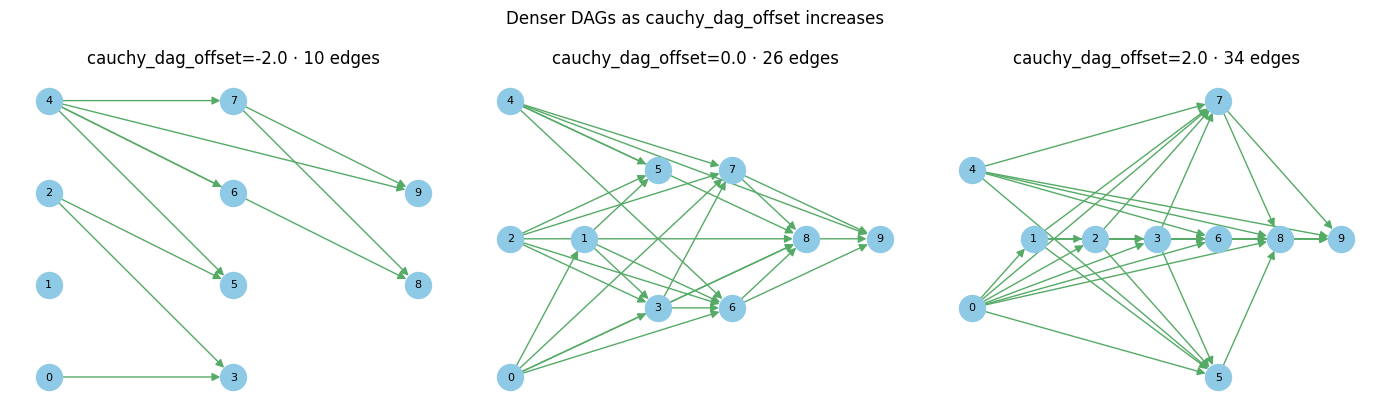

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, offset in zip(axes, [-2.0, 0.0, 2.0]):
    cfg = PriorConfig(cauchy_dag_offset=offset)
    dag_o = sample_dag(cfg, n_nodes=10, seed=3)
    G = draw_dag(dag_o, ax, title=f"cauchy_dag_offset={offset} · {dag_to_nx(dag_o).number_of_edges()} edges")
fig.suptitle("Denser DAGs as cauchy_dag_offset increases")
fig.tight_layout()
plt.show()

**Size — `min_n_nodes` / `max_n_nodes`.** The number of nodes is drawn (log-uniformly)
between these bounds. Tightening them to a fixed value pins the graph size.

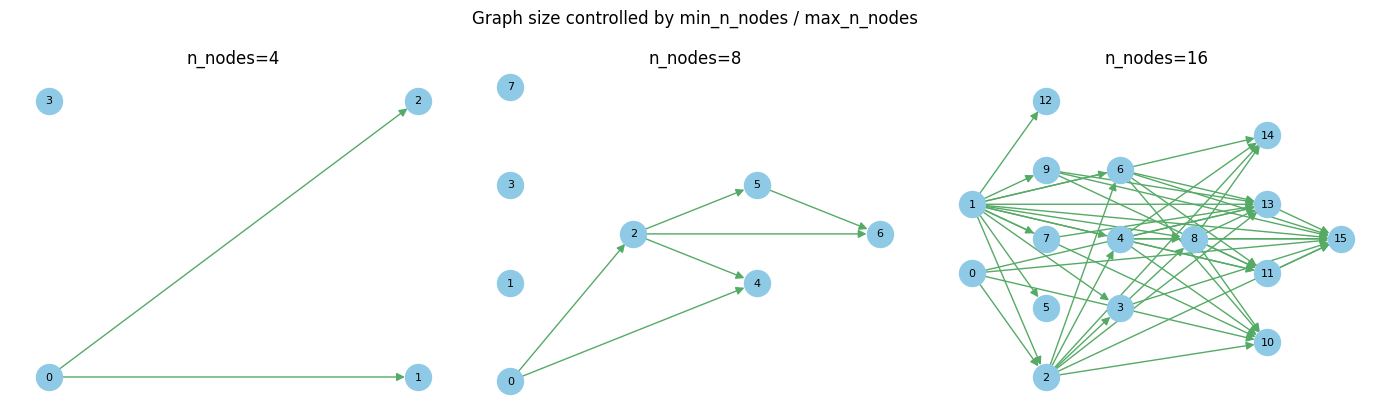

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, n in zip(axes, [4, 8, 16]):
    cfg = PriorConfig(
        min_n_nodes=n, max_n_nodes=n, # fixed size
        cauchy_dag_offset=2.0,
        # filter_unpredictable_graphs=True,
    )   
    dag_n = sample_dag(cfg, n_nodes=n, seed=5)
    draw_dag(dag_n, ax, title=f"n_nodes={n}")
fig.suptitle("Graph size controlled by min_n_nodes / max_n_nodes")
fig.tight_layout()
plt.show()

## 3. From graph to data: `RandomDataset`

[`RandomDataset`](../src/tabicl/prior/graph_lib/_dataset.py) does the full job: it samples a
DAG (respecting the config), attaches a random function to each edge, places the feature and
target columns on nodes, and evaluates the graph to produce tensors. The returned `Dataset`
keeps the DAG it used, so we can plot the graph **and** the data it generated together.

DAG used: 11 nodes, 37 edges
tensor blocks produced: {'x_num': (300, 1), 'x_cat': (300, 2), 'y_cat': (300, 1)}


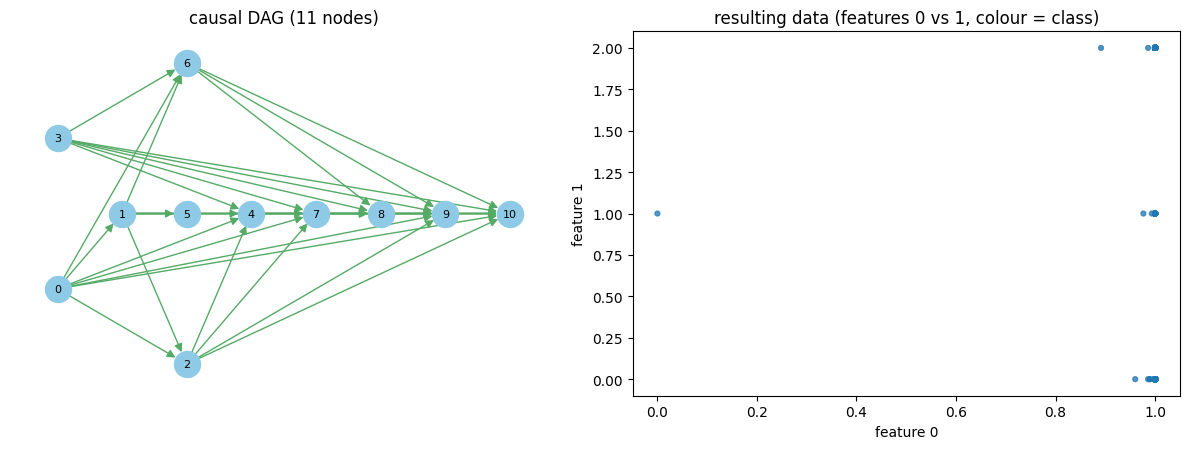

In [15]:
from tabicl.prior.graph_lib._base import DatasetProperties
from tabicl.prior.graph_lib._properties import sample_categorical_sizes
from tabicl.prior.graph_lib._dataset import RandomDataset


def sample_dataset(cfg, num_features, num_classes, n_samples, seed=SEED):
    """Sample a full (graph, tensors) dataset from a config."""
    reseed(seed)
    ctx = Context(config=cfg, device="cpu")
    props = DatasetProperties(
        n_train=n_samples, n_test=0,
        cat_sizes={
            "x": sample_categorical_sizes(num_features, ctx, max_cat_size=200),
            "y": [num_classes],   # 0 would mean a regression target
        },
    )
    return RandomDataset(ctx).sample(props)


ds = sample_dataset(config, num_features=3, num_classes=3, n_samples=300)
graph = ds.kwargs["graph"]
data = ds.get_concat_tensors()
print("DAG used:", len(graph), "nodes,", dag_to_nx(graph).number_of_edges(), "edges")
print("tensor blocks produced:", {k: tuple(v.shape) for k, v in data.items()})

# Assemble a plain (X, y) view from the concatenated blocks.
X_parts = [data[k] for k in ("x_num", "x_cat") if k in data]
X = torch.cat(X_parts, dim=-1).float()
y = data["y_cat"].view(-1).long()

fig, (ax_g, ax_d) = plt.subplots(1, 2, figsize=(12, 4.6))
draw_dag(graph, ax_g, title=f"causal DAG ({len(graph)} nodes)")
ax_d.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=12, alpha=0.75)
ax_d.set_title("resulting data (features 0 vs 1, colour = class)")
ax_d.set_xlabel("feature 0")
ax_d.set_ylabel("feature 1")
fig.tight_layout()
plt.show()

## 4. The convenient wrapper: `GraphSCM`

[`GraphSCM`](../src/tabicl/prior/_graph_scm.py) wraps `RandomDataset` and returns a ready-to-use
`(X, y)`: features are outlier-clipped, standardised, permuted and zero-padded to
`max_features`; the target is an integer class vector (or a standardised scalar when
`regression=True`). It takes the same `config`.

GraphSCM -> X (300, 4) | y (300,) | classes [0, 1, 2]


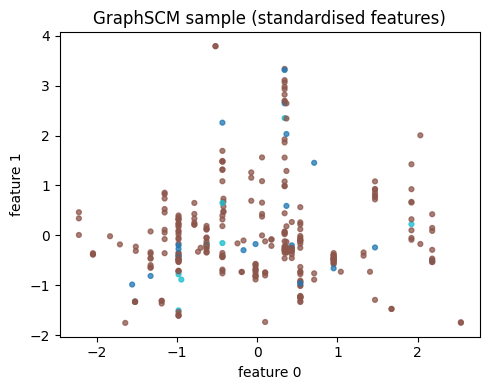

In [16]:
from tabicl.prior._graph_scm import GraphSCM

reseed(2)
with torch.no_grad():
    gscm = GraphSCM(
        seq_len=300, num_features=4, max_features=4, num_classes=3,
        regression=False, config=config, device="cpu",
    )
    Xg, yg = gscm()
print("GraphSCM ->", "X", tuple(Xg.shape), "| y", tuple(yg.shape), "| classes", torch.unique(yg).tolist())

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(Xg[:, 0], Xg[:, 1], c=yg, cmap="tab10", s=12, alpha=0.75)
ax.set_title("GraphSCM sample (standardised features)")
ax.set_xlabel("feature 0")
ax.set_ylabel("feature 1")
fig.tight_layout()
plt.show()

## 5. The public API: `PriorDataset`

In training you never touch the internals — you iterate
[`PriorDataset`](../src/tabicl/prior/_dataset.py) with `prior_type="graph_scm"` and your
`config`. It yields an infinite stream of batches `(X, y, d, seq_lens, train_sizes)`, taking
care of group/subgroup structure, validity checks and feature filtering. The same `config`
object flows all the way down to the DAG sampler we started from.

PriorDataset(
  task: classification
  prior_type: graph_scm
  batch_size: 6
  batch_size_per_gp: 2
  features: 2 - 4
  max classes: 3
  seq_len: None - 300
  sequence length varies across groups: False
  train_size: 0.1 - 0.9
  device: cpu
)

X: (6, 300, 4) | y: (6, 300)
active features per dataset: [4, 4, 3, 3, 2, 2]
train/test split positions:  [69, 69, 69, 69, 69, 69]


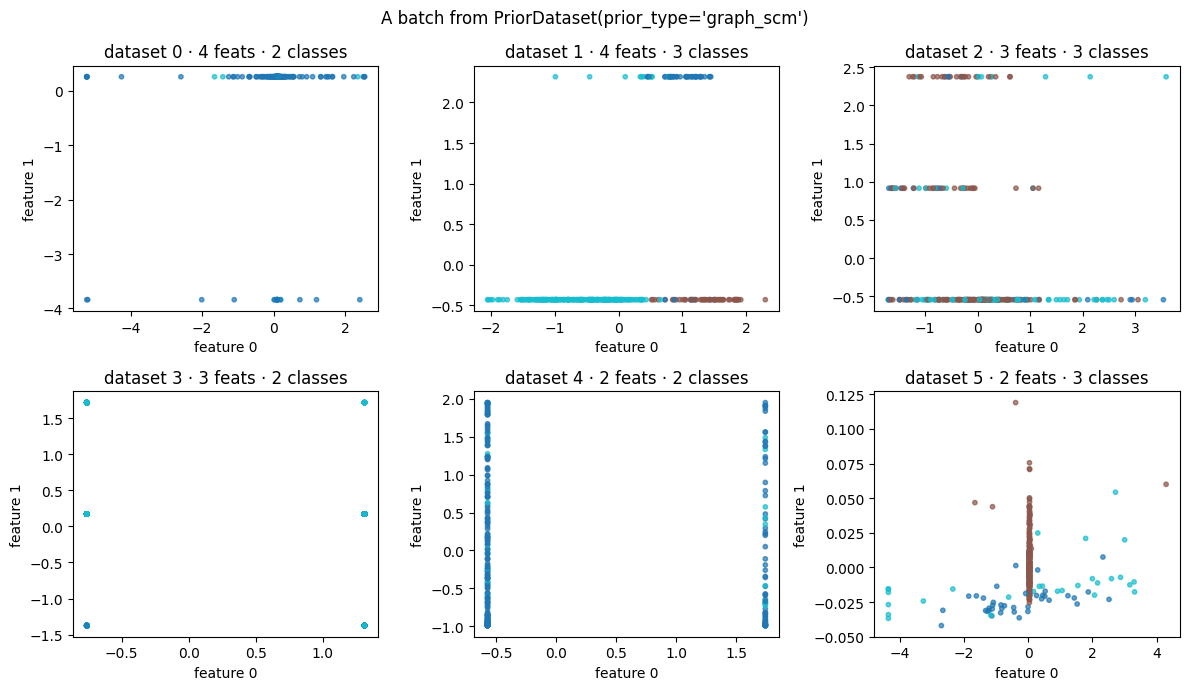

In [17]:
from tabicl.prior import PriorDataset

prior = PriorDataset(
    prior_type="graph_scm",
    config=config,          # <- the very same PriorConfig
    regression=False,
    batch_size=6, batch_size_per_gp=2,
    min_features=2, max_features=4, max_classes=3,
    max_seq_len=300, n_jobs=1, device="cpu",
)
print(prior)

Xb, yb, db, seq_lens, train_sizes = prior.get_batch()
print("\nX:", tuple(Xb.shape), "| y:", tuple(yb.shape))
print("active features per dataset:", db.tolist())
print("train/test split positions: ", train_sizes.tolist())

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for k, ax in enumerate(axes.ravel()):
    ax.scatter(Xb[k, :, 0], Xb[k, :, 1], c=yb[k], cmap="tab10", s=10, alpha=0.7)
    ax.set_title(f"dataset {k} · {int(db[k])} feats · {len(torch.unique(yb[k]))} classes")
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
fig.suptitle("A batch from PriorDataset(prior_type='graph_scm')")
fig.tight_layout()
plt.show()

## 6. Changing the config end-to-end

Because the config threads through every layer, editing one field changes the data the model
trains on. Here we compare **small vs large** causal graphs by pinning `max_n_nodes`, keeping
everything else fixed. Larger graphs give deeper causal chains and more intricate feature
relationships.

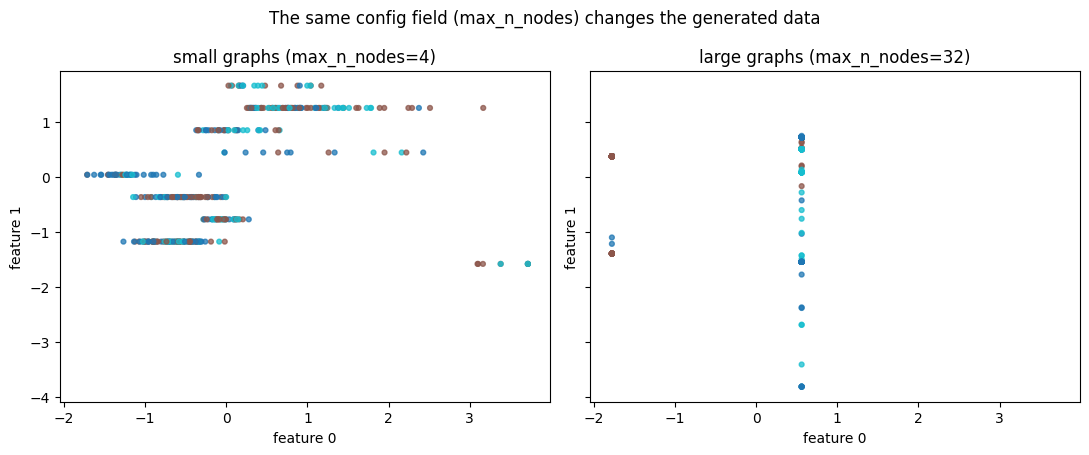

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, (label, cfg) in zip(
    axes,
    [("small graphs (max_n_nodes=4)", PriorConfig(min_n_nodes=2, max_n_nodes=4)),
     ("large graphs (max_n_nodes=32)", PriorConfig(min_n_nodes=24, max_n_nodes=32))],
):
    reseed(7)
    p = PriorDataset(
        prior_type="graph_scm", config=cfg, regression=False,
        batch_size=1, batch_size_per_gp=1,
        min_features=2, max_features=4, max_classes=3,
        max_seq_len=400, n_jobs=1, device="cpu",
    )
    Xc, yc, dc, _, _ = p.get_batch()
    ax.scatter(Xc[0, :, 0], Xc[0, :, 1], c=yc[0], cmap="tab10", s=12, alpha=0.75)
    ax.set_title(label)
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
fig.suptitle("The same config field (max_n_nodes) changes the generated data")
fig.tight_layout()
plt.show()

## Recap

- **`PriorConfig` is the single source of truth** for the `graph_scm` prior; pass it to
  `PriorDataset(prior_type="graph_scm", config=…)` and it propagates all the way down.
- The pipeline is **config → DAG (`RandomCauchyDAG`) → data (`RandomDataset`) →
  ready tensors (`GraphSCM`) → batches (`PriorDataset`)**.
- Graph-shaping knobs live on the config: `min_n_nodes` / `max_n_nodes` (size),
  `cauchy_dag_offset` (density); edge-function and categorical behaviour live in
  `fct_types`, `multi_fct_types`, `cat_modes`; dataset quality filters in
  `filter_unpredictable_datasets`, `remove_trivial_datasets`, ….

From here, read `graph_lib/_graph_function.py` for how edge functions are sampled and
`graph_lib/_dataset.py` for how feature/target columns are placed on the DAG.

In [11]:
print("done")

done
